# Transaction Fraud Detection using Machine Learning

##  Problem Statement

Financial fraud has become one of the major challenges faced by banks and financial institutions. Detecting fraudulent transactions manually is difficult due to the increasing number of daily transactions.

The objective of this project is to build a Machine Learning model that can classify transactions as Fraudulent or Genuine using transaction details and customer behavior.

##  Objectives

- Load and understand the dataset.
- Clean and preprocess the data.
- Train multiple Machine Learning models.
- Compare model performance.
- Predict fraudulent transactions accurately.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


## Load Dataset

The dataset is loaded into a Pandas DataFrame so that it can be analyzed and used for building machine learning models.


In [ ]:
df = pd.read_csv("../data/Transaction Fraud Detection for SafeBank.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


: 

: 

In [ ]:
df.head()

,CustomerID,TransactionAmount,TransactionTime,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
0,1352,1834.26,2023-01-01 13:27:00,Bangalore,Online,89,0.10,Mobile,0
1,1562,3130.03,2023-01-01 04:52:00,Chennai,ATM,44,0.63,Tablet,0
2,1828,3030.78,2023-01-01 13:17:00,Chennai,Bank Transfer,97,0.62,Tablet,1
3,1399,493.04,2023-01-01 21:05:00,Delhi,POS,13,0.24,Mobile,0
4,1740,1298.36,2023-01-01 03:29:00,Chennai,Online,24,0.98,Desktop,0


: 

: 

: 

## Dataset Information

This section provides an overview of the dataset, including the number of rows and columns, column names, data types, missing values, duplicate values, and statistical summary.

In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (1000, 9)

Column Names:
Index(['CustomerID', 'TransactionAmount', 'TransactionTime', 'Location',
       'TransactionType', 'AccountAgeMonths', 'BehaviorScore', 'DeviceUsed',
       'IsFraud'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1000 non-null   int64  
 1   TransactionAmount  1000 non-null   float64
 2   TransactionTime    1000 non-null   str    
 3   Location           1000 non-null   str    
 4   TransactionType    1000 non-null   str    
 5   AccountAgeMonths   1000 non-null   int64  
 6   BehaviorScore      1000 non-null   float64
 7   DeviceUsed         1000 non-null   str    
 8   IsFraud            1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


: 

: 

: 

In [ ]:
print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Statistical Summary:


,CustomerID,TransactionAmount,AccountAgeMonths,BehaviorScore,IsFraud
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1503.398000,1997.250540,59.792000,0.548200,0.04600
std,282.614707,1974.282111,33.652537,0.254637,0.20959
min,1003.000000,5.020000,1.000000,0.100000,0.00000
25%,1259.000000,583.137500,33.000000,0.330000,0.00000
50%,1508.000000,1415.500000,59.500000,0.550000,0.00000
75%,1739.000000,2748.712500,89.000000,0.760000,0.00000
max,1997.000000,16445.260000,119.000000,1.000000,1.00000



Missing Values:
CustomerID           0
TransactionAmount    0
TransactionTime      0
Location             0
TransactionType      0
AccountAgeMonths     0
BehaviorScore        0
DeviceUsed           0
IsFraud              0
dtype: int64

Duplicate Rows:
0


: 

: 

: 

# Data Preprocessing
 
Data preprocessing is an important step in machine learning. It prepares the dataset by removing unnecessary information and converting categorical data into numerical form so that machine learning algorithms can process it efficiently.

In [ ]:
# Remove CustomerID column

df.drop("CustomerID", axis=1, inplace=True)


: 

: 

: 

## Encoding Categorical Variables
 
Machine learning algorithms cannot work directly with text data. Therefore, categorical columns such as **Location**, **TransactionType**, and **DeviceUsed** are converted into numerical values using Label Encoding.

In [ ]:

encoder = LabelEncoder()


categorical_columns = ["Location", "TransactionType", "DeviceUsed"]


for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])
                                       
df.head()

,TransactionAmount,TransactionTime,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
0,1834.26,2023-01-01 13:27:00,0,2,89,0.10,1,0
1,3130.03,2023-01-01 04:52:00,1,0,44,0.63,2,0
2,3030.78,2023-01-01 13:17:00,1,1,97,0.62,2,1
3,493.04,2023-01-01 21:05:00,2,3,13,0.24,1,0
4,1298.36,2023-01-01 03:29:00,1,2,24,0.98,0,0


: 

: 

: 

In [ ]:

df.drop("TransactionTime", axis=1, inplace=True)

df.head()

,TransactionAmount,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
0,1834.26,0,2,89,0.10,1,0
1,3130.03,1,0,44,0.63,2,0
2,3030.78,1,1,97,0.62,2,1
3,493.04,2,3,13,0.24,1,0
4,1298.36,1,2,24,0.98,0,0


: 

: 

: 

In [ ]:

X = df.drop("IsFraud", axis=1)

y = df["IsFraud"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 6)
Target Shape: (1000,)


: 

: 

: 

## Train-Test Split

The dataset is divided into two parts:

 **Training Data (80%)**: Used to train the machine learning model.
 **Testing Data (20%)**: Used to evaluate the model's performance on unseen data.

This helps determine how well the model generalizes to new data.

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (800, 6)
Testing Features : (200, 6)
Training Target  : (800,)
Testing Target   : (200,)


: 

: 

: 

In [ ]:
df.columns.tolist()

['TransactionAmount',
 'Location',
 'TransactionType',
 'AccountAgeMonths',
 'BehaviorScore',
 'DeviceUsed',
 'IsFraud']

: 

: 

: 

In [ ]:
df.head()

,TransactionAmount,Location,TransactionType,AccountAgeMonths,BehaviorScore,DeviceUsed,IsFraud
0,1834.26,0,2,89,0.10,1,0
1,3130.03,1,0,44,0.63,2,0
2,3030.78,1,1,97,0.62,2,1
3,493.04,2,3,13,0.24,1,0
4,1298.36,1,2,24,0.98,0,0


: 

: 

: 

## Feature Scaling

Machine learning algorithms such as **K-Nearest Neighbors (KNN)** calculate distances between data points.

Since different features may have different ranges, feature scaling is applied using **StandardScaler** to standardize the data.

This improves model performance and ensures that no feature dominates because of its larger values.

In [ ]:


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


: 

: 

: 

# Machine Learning Models

In this section, different machine learning algorithms are implemented to classify transactions as **Fraudulent** or **Genuine**.

The following algorithms are used:

1. K-Nearest Neighbors (KNN)
2. Decision Tree
3. Random Forest
4. Naive Bayes
5. Ensemble Learning (Voting Classifier)

Each model is evaluated using:
-Accuracy Score
 Confusion Matrix
 Classification Report

## 1. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification. It classifies a new data point based on the majority class of its nearest neighbors.

In [ ]:

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.945

Confusion Matrix
[[189   0]
 [ 11   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       189
           1       0.00      0.00      0.00        11

    accuracy                           0.94       200
   macro avg       0.47      0.50      0.49       200
weighted avg       0.89      0.94      0.92       200



c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


: 

: 

: 

## 2. Decision Tree

Decision Tree is a supervised learning algorithm that classifies data by creating decision rules based on feature values. It is easy to understand and interpret.

In [ ]:


dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy:

 0.865

Confusion Matrix
[[173  16]
 [ 11   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       189
           1       0.00      0.00      0.00        11

    accuracy                           0.86       200
   macro avg       0.47      0.46      0.46       200
weighted avg       0.89      0.86      0.88       200



: 

: 

: 

## 3. Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [ ]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.945

Confusion Matrix
[[189   0]
 [ 11   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       189
           1       0.00      0.00      0.00        11

    accuracy                           0.94       200
   macro avg       0.47      0.50      0.49       200
weighted avg       0.89      0.94      0.92       200



c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


: 

: 

: 

## 4. Naive Bayes

Naive Bayes is a probabilistic machine learning algorithm based on Bayes' theorem. It is simple, fast, and works well for classification problems.

In [ ]:


nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.945

Confusion Matrix
[[189   0]
 [ 11   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       189
           1       0.00      0.00      0.00        11

    accuracy                           0.94       200
   macro avg       0.47      0.50      0.49       200
weighted avg       0.89      0.94      0.92       200



c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


: 

: 

: 

## 5. Ensemble Learning (Voting Classifier)

Ensemble Learning combines multiple machine learning models to make better predictions. In this project, a Voting Classifier combines KNN, Decision Tree, and Naive Bayes.

In [ ]:


ensemble = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('nb', GaussianNB())
    ],
    voting='hard'
)

ensemble.fit(X_train, y_train)

y_pred_ensemble = ensemble.predict(X_test)

ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)

print("Ensemble Accuracy:", ensemble_accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_ensemble))

print("\nClassification Report")
print(classification_report(y_test, y_pred_ensemble))

Ensemble Accuracy: 0.945

Confusion Matrix
[[189   0]
 [ 11   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       189
           1       0.00      0.00      0.00        11

    accuracy                           0.94       200
   macro avg       0.47      0.50      0.49       200
weighted avg       0.89      0.94      0.92       200



c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\acer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


: 

: 

: 

# Model Comparison

The performance of all machine learning algorithms is compared using their accuracy scores.

In [ ]:


results = pd.DataFrame({
    "Algorithm": [
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "Ensemble Learning"
    ],
    "Accuracy": [
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        nb_accuracy,
        ensemble_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Algorithm,Accuracy
0,K-Nearest Neighbors,0.945
2,Random Forest,0.945
3,Naive Bayes,0.945
4,Ensemble Learning,0.945
1,Decision Tree,0.865


: 

: 

: 

In [ ]:


best_model = results.iloc[0]

print("Best Model :", best_model["Algorithm"])
print("Accuracy   :", round(best_model["Accuracy"] * 100, 2), "%")

Best Model : K-Nearest Neighbors
Accuracy   : 94.5 %


: 

: 

: 

# Model Performance Visualization

The accuracy scores of all machine learning models are visualized using a bar chart. This comparison helps identify the best-performing algorithm for transaction fraud detection based on prediction accuracy.

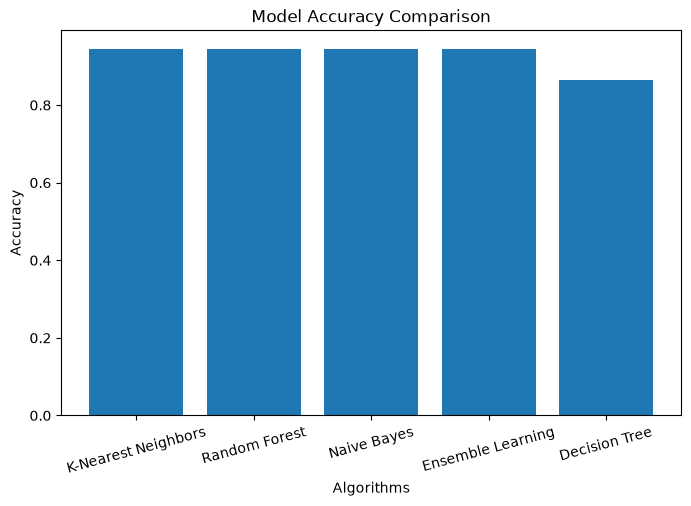

: 

: 

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Algorithm"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

# Conclusion

This project successfully developed a machine learning-based fraud detection system to classify banking transactions as fraudulent or genuine.

Five machine learning algorithms were implemented and evaluated. Their performance was compared using accuracy scores, and the best-performing model was identified.

The developed system demonstrates how machine learning techniques can assist financial institutions in improving fraud detection and reducing financial losses.

# Saving the Trained Model

The best-performing machine learning model is saved using the Joblib library. This enables the trained model to be reused later for predictions without retraining.

In [ ]:
import joblib

: 

: 

: 

In [ ]:
print(rf)

NameError: name 'rf' is not defined

: 

: 

: 